In [1]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np

from dotenv import load_dotenv
load_dotenv()
# DATASET_PATH=os.getenv("DATASET_DIRECTORY")
DATASET_PATH=os.path.join("/data/IcaRAus/generated_datasets")
# MODEL_TRAINING_DATASET_PATH=os.getenv("MODEL_TRAINING_DATASET_PATH")
MODEL_TRAINING_DATASET_PATH="/data/IcaRAus/generated_datasets"
GENERATED_DATASETS_PATH=os.getenv("GENERATED_DATASETS_PATH")
GENERATED_DATASETS_PATH="/data/IcaRAus/generated_datasets"
ICARAUS_UNET_MODEL_STATE_DICT_PATH = "/home/david/Documents/odometry/submodules/mmwave_model_integrator/notebooks/working_dir/IcaRAus_unet/"

sys.path.append("../")
from cpsl_datasets._base_training_ds import _BaseTrainingDS

from mmwave_model_integrator.input_encoders._input_encoder import _InputEncoder
from mmwave_model_integrator.ground_truth_encoders._gt_encoder import _GTEncoder
from mmwave_model_integrator.plotting.plotter_grids import PlotterGrids



from mmwave_model_integrator.model_runner.IcaRAus_unet_runner import IcaRAusUnetRunner
from mmwave_model_integrator.decoders._decoder import _Decoder
# from mmwave_model_integrator.plotting.movie_generator_hermes import MovieGeneratorHermes
# from mmwave_model_integrator.analyzers.analyzer_hermes import AnalyzerHermes


In [ ]:
#initialize the dataset
# config_label = "IcaRAus_ugv_unet_50fh_wilk_cpsl_north_1st_occluded_rt_gt_olp_pts_no_gt_filter"
config_label = "IcaRAus_ugv_unet_50fh_wilk_cpsl_north_1st_no_clustering"

dataset_path = os.path.join(DATASET_PATH,"{}_train".format(config_label))
dataset = _BaseTrainingDS(
    dataset_path=dataset_path,
    input_folder="grids",
    label_folder="gt_grids"
)
print(dataset_path)

did not find input samples
did not find label samples
/data/IcaRAus/generated_datasets/IcaRAus_ugv_gnn_50fh_wilk_cpsl_north_1st_occluded_no_rt_gt_no_rt_pts_no_gt_filter_0_25_eps_10_min_20_sub_train


In [21]:
#initialize the encoder and decoder
input_encoder = _InputEncoder()
ground_truth_encoder = _GTEncoder()
plotter = PlotterGrids(
    max_detection_range=8.0,
    grid_resolution_m=0.1
)

input_dimmensions = (160,160)
runner = IcaRAusUnetRunner(
    state_dict_path=os.path.join(ICARAUS_UNET_MODEL_STATE_DICT_PATH,"IcaRAus_unet_base.pth"),
    cuda_device="cpu",
    input_dimmensions=input_dimmensions,
    encoder_out_channels = (64,128),
    decoder_input_channels = (256,128)
)

prediction_decoder = _Decoder()

# movie_generator = MovieGeneratorHermes(
#     cpsl_dataset=dataset,
#     plotter=plotter,
#     input_encoder=input_encoder,
#     runner=runner,
#     decoder=prediction_decoder,
#     ground_truth_encoder=ground_truth_encoder,
#     temp_dir_path=os.path.join("/home/cpsl/Downloads/datasets","Hermes")
# )

# analyzer = AnalyzerHermes(
#     cpsl_dataset=dataset,
#     input_encoder=input_encoder,
#     model_runner=runner,
#     prediction_decoder=prediction_decoder,
#     ground_truth_encoder=ground_truth_encoder,
#     temp_dir_path=os.getenv("ANALYZER_TEMP_DIRECTORY")
# )

_ModelRunner: using CPU
Total number of parameters: 1864257


(161, 161)
1


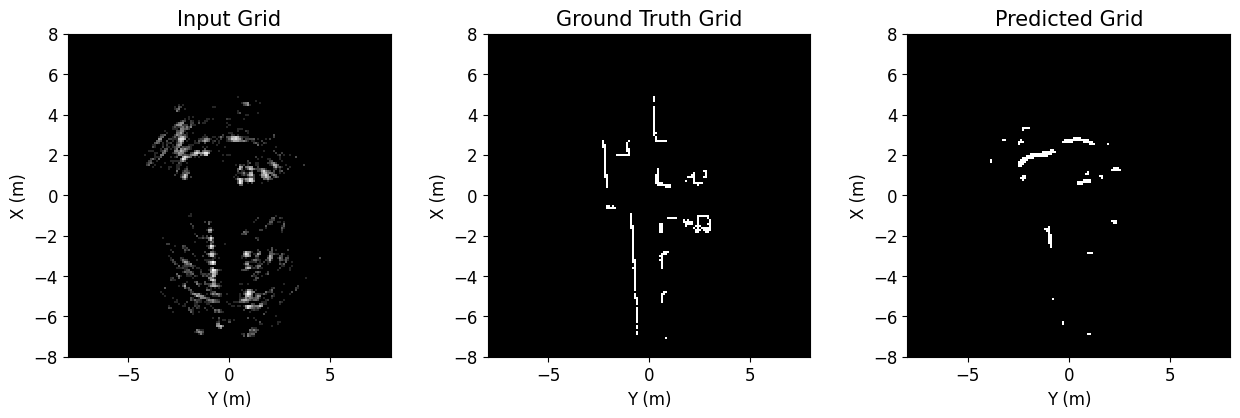

In [26]:
idx=260
input_data = dataset.get_input_data(idx=idx)
labels = dataset.get_label_data(idx=idx)

print(input_data.shape)
print(labels.max())

plotter.plot_compilation(
    input_data=input_data,
    gt_data=labels,
    input_encoder=input_encoder,
    ground_truth_encoder=ground_truth_encoder,
    runner=runner,
    show=True
)

(160, 160)


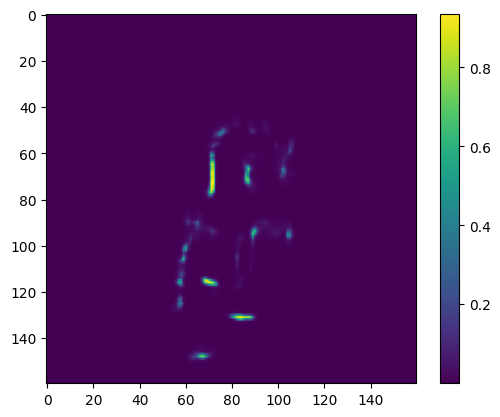

In [ ]:
raw_resp_raw = runner.make_prediction_raw(input=input_encoder.encode(input_data))
raw_resp_raw = np.flip(raw_resp_raw)
print(raw_resp_raw.shape)
plt.imshow(raw_resp_raw)
plt.colorbar()

In [ ]:
#speed comparison
from tqdm import tqdm

for i in tqdm(range(dataset.num_frames)):

    # adc_cube = dataset.get_radar_data(idx=1)
    # try: #try accessing the full odometry data
    #     vel_data = np.mean(dataset.get_vehicle_odom_data(idx)[:,8:11],axis=0)
    # except AssertionError: #if not just get the x velocity (forward)
    #     vel = np.mean(dataset.get_vehicle_vel_data(idx)[:,1])
    #     vel_data = np.array([vel,0,0])
    # rng_az_resp = input_encoder.encode(adc_cube,vel_data)
    if input_encoder.full_encoding_ready:
        pred = runner.make_prediction(input=input_encoder.encode(input_data))


 12%|█▏        | 848/7086 [00:57<07:01, 14.79it/s]


KeyboardInterrupt: 

In [ ]:
chamfer,hausdorff, chamfer_radarHD, modified_hausdorff_radarHD = \
    analyzer.compute_all_distance_metrics(
        save_to_file=True,
        file_name=dataset_name
    )
analyzer.show_all_summary_statistics(
    chamfer_distances=chamfer,
    hausdorff_distances=hausdorff,
    chamfer_distances_radarHD=chamfer_radarHD,
    modified_hausdorff_distances_radarHD=modified_hausdorff_radarHD
)

Analyzer.compute_all_distance_metrics: Computing distance metrics


100%|██████████| 694/694 [00:32<00:00, 21.33it/s]

Analyzer.compute_all_distance_metrics: number failed predictoins 0 of 694 (0.0%)


,Metric,Hausdorff,Modified Hausdorff (radarHD),Chamfer,Chamfer (radarHD)
0,Mean,4.765181,0.087879,1.310504,0.309258
1,Median,4.851610,0.088880,1.203505,0.297904
2,90th percentile,6.275602,0.093919,1.804786,0.385356


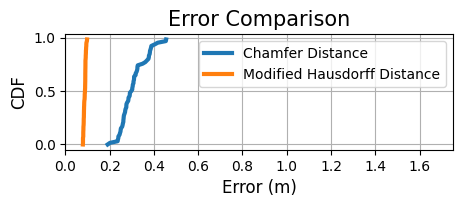

In [ ]:
plotter.plot_distance_metrics_cdfs(
    # chamfer_distances=chamfer,
    # hausdorf_distances=hausdorff,
    chamfer_distances_radarHD=chamfer_radarHD,
    modified_hausdorf_distances_radarHD=modified_hausdorff_radarHD
)

100%|██████████| 67/67 [00:06<00:00, 10.22it/s]


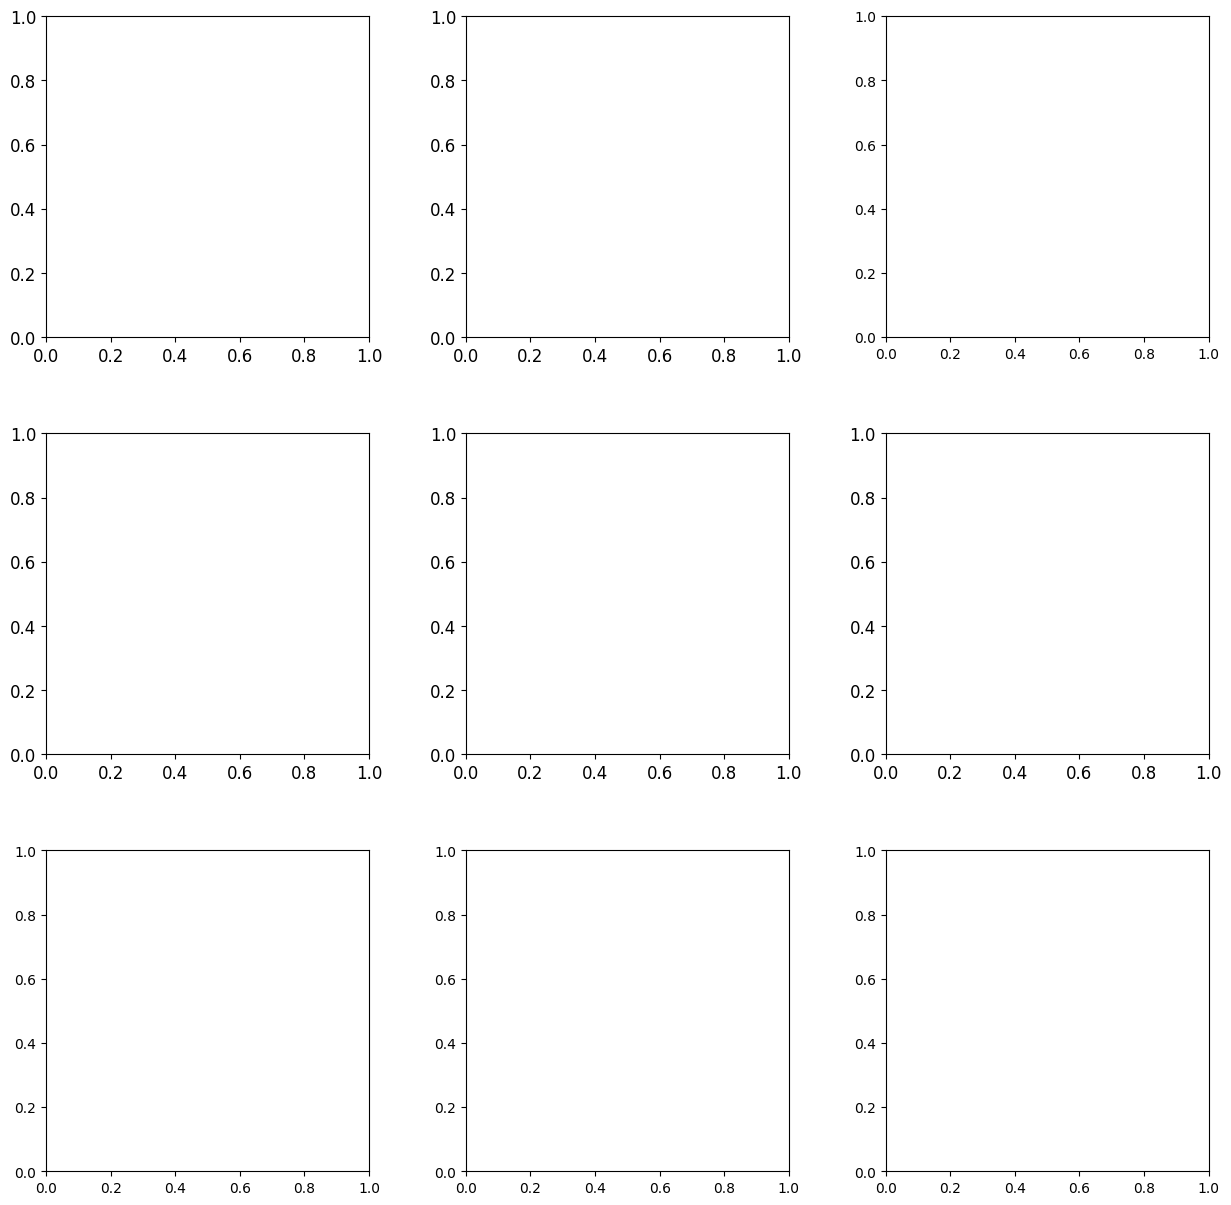

In [ ]:
movie_generator.initialize_figure(
    nrows=3,
    ncols=3,
    figsize=(15,15),
    wspace=0.3,
    hspace=0.3
)

movie_generator.generate_movie_frames()

fps = 1 / (1e-3 * cfg_manager.frameCfg_periodicity_ms)
movie_generator.save_movie(video_file_name="{}_revised_mini.mp4".format(dataset_name),fps=fps)